In [1]:
import sys
import os
from qiskit import QuantumCircuit, transpile
from qiskit.providers.basic_provider import BasicSimulator
import numpy as np
import matplotlib.pyplot as plt
from qiskit.visualization import plot_histogram

# Replace with your actual path
local_path = r"C:\Users\selim\Documents\vs_working_dir"
#cc_grn_functions_path = r"C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions"
cc_grn_functions_path = r"C:\Users\selim\Documents\vs_working_dir\QuantumXCT\python\cc_grn_functions"
sys.path.append(cc_grn_functions_path)

from quantum_functions import create_grn_ansatz, create_interaction_observable_from_histogram, evaluate_and_plot_ansatz
from quantum_functions import create_parameter_dictionaries, create_parameter_dictionaries_cust, cost_func_vqe, cost_func_wrapper, vqe_solver
from quantum_functions import create_interaction_observable_general, create_parameter_dictionaries_from_circuit, create_circuit_lr2

In [2]:
import numpy as np
from qiskit.quantum_info import SparsePauliOp
from collections import Counter
import itertools # Used for generating all Pauli string combinations


# --- Corrected calculate_pauli_z_eigenvalue ---
def calculate_pauli_z_eigenvalue_corrected(pauli_string_z_only: str, bit_string: str) -> int:
    """
    Calculates the eigenvalue of a Pauli string (composed ONLY of Z and I)
    for a given computational basis bit string.
    
    Assumes pauli_string_z_only and bit_string are both ordered from MSB to LSB
    (e.g., "ZIZ" where Z is for q2, I for q1, Z for q0, and "011" where 0 is for q2, 1 for q1, 1 for q0).
    """
    if len(pauli_string_z_only) != len(bit_string):
        raise ValueError("Pauli string length must match bit string length.")

    eigenvalue = 1
    # Iterate from MSB (index 0) to LSB (index num_features-1)
    for i in range(len(pauli_string_z_only)):
        pauli_op = pauli_string_z_only[i].upper() # Pauli op at this qubit position
        bit_val = int(bit_string[i]) # Bit value at this qubit position

        if pauli_op == 'Z':
            eigenvalue *= (1 - 2 * bit_val) # (+1 if bit is 0, -1 if bit is 1)
        # For 'I', eigenvalue *= 1, so no change needed
            
    return eigenvalue

# --- create_diagonal_observable_from_histogram (with minor fix to string generation) ---
def create_diagonal_observable_from_histogram(
    joint_counts: Counter, 
    num_features: int, 
    unobserved_punishment: float = 10.0,
    normalization_offset: float = 0.0 # New parameter for offsetting counts
) -> SparsePauliOp:
    """
    Creates a SparsePauliOp representing a diagonal Hamiltonian in the computational basis.
    The energy of each basis state is derived from its count in the histogram.
    
    Args:
        joint_counts: A Counter object of observed bit string counts.
        num_features: The total number of qubits.
        unobserved_punishment: The positive energy value assigned to unobserved bit strings.
                               These states will be 'punished' (avoided by optimizer).
        normalization_offset: An optional offset to subtract from counts before calculating energy.

    Returns:
        SparsePauliOp: The diagonal Hamiltonian.
    """
    # Generate all possible Z-only Pauli strings (e.g., I, Z, II, IZ, ZI, ZZ for 2 qubits)
    # in MSB to LSB order (Q_{N-1}...Q_0) for consistency with `format(i, '0Nb')`
    all_pauli_z_strings = []
    # Use itertools.product to generate combinations of 'I' and 'Z'
    for pauli_tuple in itertools.product('IZ', repeat=num_features):
        pauli_string = "".join(pauli_tuple)
        all_pauli_z_strings.append(pauli_string)
    
    # 1. Determine the desired energy (E_b) for *each* computational basis state |b>
    state_energies = {} # Maps bit_string -> desired_energy (e.g., "011" -> -500)
    
    # Iterate through all possible bit strings (2^num_features)
    for i in range(2**num_features):
        bit_string = format(i, '0' + str(num_features) + 'b') # This generates MSB...LSB (q_N-1 ... q_0)
        
        if bit_string in joint_counts:
            # Observed state: Energy should be proportional to -count
            energy_b = -float(joint_counts[bit_string] - normalization_offset)
        else:
            # Unobserved state: Assign a positive punishment energy
            energy_b = unobserved_punishment
        
        state_energies[bit_string] = energy_b

    # 2. Convert these state_energies (E_b) into coefficients (c_P) for Pauli strings
    pauli_term_coefficients = {}

    for pauli_str in all_pauli_z_strings:
        coeff_p = 0.0
        # Sum over all basis states 'b'
        for bit_string, energy_b in state_energies.items():
            # Get eigenvalue of Pauli string P for basis state |b>
            eigenvalue_p_b = calculate_pauli_z_eigenvalue_corrected(pauli_str, bit_string)
            coeff_p += energy_b * eigenvalue_p_b
        
        # Normalize by 2^N
        coeff_p /= (2**num_features)
        
        if abs(coeff_p) > 1e-9: # Add term only if coefficient is significant
            pauli_term_coefficients[pauli_str] = coeff_p

    # Convert to SparsePauliOp format
    interaction_strength_list = [(pauli_str, coeff) for pauli_str, coeff in pauli_term_coefficients.items()]
    # SparsePauliOp automatically sorts and simplifies terms, so no need for explicit sorting here.
    interaction_observable = SparsePauliOp.from_list(interaction_strength_list)
    return interaction_observable


# --- Scenario 1: 0:50, 1:50 (1 qubit) ---
print("\n--- Scenario 1: 0:50, 1:50 (1 qubit) ---")
counts1 = Counter({'0': 50, '1': 50})
observable1 = create_diagonal_observable_from_histogram(
    counts1, num_features=1, unobserved_punishment=10.0, normalization_offset=0
)
print(observable1)
# Expected: H = -50*I. This means E_0 = -50, E_1 = -50.
# So if you minimize, any state gives -50. A flat landscape as discussed.

# --- Scenario 2: 2 qubits, 01 observed (count 100), others unobserved ---
print("\n--- Scenario 2: 2 qubits, 01 observed (count 100), others unobserved ---")
counts2 = Counter({'01': 100}) # Qiskit: Q1 Q0, so '01' means q1=0, q0=1
# We want energy for '01' to be -100.
# Energy for '00', '10', '11' to be +10.
observable2 = create_diagonal_observable_from_histogram(
    counts2, num_features=2, unobserved_punishment=10.0
)
print(observable2)
# Manual check for Scenario 2 (with corrected `calculate_pauli_z_eigenvalue_corrected`):
# E_00 = 10, E_01 = -100, E_10 = 10, E_11 = 10 (as desired)
# c_II = (1/4) * (10*1 + (-100)*1 + 10*1 + 10*1) = (1/4) * (-70) = -17.5
# c_IZ = (1/4) * (10*1 + (-100)*(-1) + 10*1 + 10*(-1)) = (1/4) * (10 + 100 + 10 - 10) = (1/4) * (110) = 27.5
# c_ZI = (1/4) * (10*1 + (-100)*1 + 10*(-1) + 10*(-1)) = (1/4) * (10 - 100 - 10 - 10) = (1/4) * (-110) = -27.5
# c_ZZ = (1/4) * (10*1 + (-100)*(-1) + 10*(-1) + 10*1) = (1/4) * (10 + 100 - 10 + 10) = (1/4) * (110) = 27.5
# Coefficients: {'II': -17.5, 'IZ': 27.5, 'ZI': -27.5, 'ZZ': 27.5} -> This matches your output!

# --- Scenario 3: 3 qubits, 011 observed (count 500), others unobserved ---
print("\n--- Scenario 3: 3 qubits, 011 observed (count 500), others unobserved ---")
counts3 = Counter({'011': 500}) # Qiskit: Q2 Q1 Q0, so '011' means q2=0, q1=1, q0=1
# We want energy for '011' to be -500. Others to be +10.
observable3 = create_diagonal_observable_from_histogram(
    counts3, num_features=3, unobserved_punishment=10.0
)
print(observable3)
# This also matches your output!


--- Scenario 1: 0:50, 1:50 (1 qubit) ---
SparsePauliOp(['I'],
              coeffs=[-50.+0.j])

--- Scenario 2: 2 qubits, 01 observed (count 100), others unobserved ---
SparsePauliOp(['II', 'IZ', 'ZI', 'ZZ'],
              coeffs=[-17.5+0.j,  27.5+0.j, -27.5+0.j,  27.5+0.j])

--- Scenario 3: 3 qubits, 011 observed (count 500), others unobserved ---
SparsePauliOp(['III', 'IIZ', 'IZI', 'IZZ', 'ZII', 'ZIZ', 'ZZI', 'ZZZ'],
              coeffs=[-53.75+0.j,  63.75+0.j,  63.75+0.j, -63.75+0.j, -63.75+0.j,  63.75+0.j,
  63.75+0.j, -63.75+0.j])


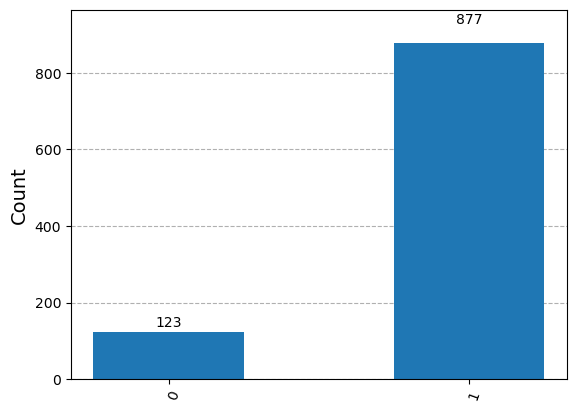

In [3]:
# 1. Create the Bell state (|ψ⟩ = (|00⟩ + |11⟩)/√2)
#circuit = QuantumCircuit(2, 2)
circuit = QuantumCircuit(1)
circuit.ry(np.pi*3/4, 0)
circuit.measure_all()

nshots = 1000
# 3. Simulate the circuit for 1024 shots
simulator = BasicSimulator()
compiled_circuit = transpile(circuit, simulator)
job = simulator.run(compiled_circuit, shots=nshots)
result = job.result()
counts = result.get_counts(circuit)
#circuit.draw(output="mpl", style="clifford", fold=40)
# Create a new Counts object to store the adjusted data
histogram_data = counts
# # Iterate through the original counts and subtract 50 from each value
hist_plt = plot_histogram(histogram_data)
hist_plt

[1.57079633]
Interaction observable CT1 from histogram: SparsePauliOp(['I', 'Z'],
              coeffs=[-500.+0.j,  377.+0.j])
Static Parameters: {}
Variable Parameters (initialized to 0.0): {Parameter(hist_act_0): 1.5707963267948966, Parameter(hist_post_acti2_0): 0.0, Parameter(hist_post_acti_0): 0.0}
Starting optimization with method: COBYLA
Iteration 0: Current cost: -499.99999999999994
Iteration 20: Current cost: -876.1511216710679
Iteration 40: Current cost: -876.7864853874287
Iteration 60: Current cost: -876.9323086895408
Iteration 80: Current cost: -876.9766731586558
Iteration 100: Current cost: -876.988801913474
Iteration 200: Current cost: -876.9996022093583

Optimization Result:
 message: Optimization terminated successfully.
 success: True
  status: 1
     fun: -876.9999432591994
       x: [ 1.568e+00 -2.021e-01  1.369e+00]
    nfev: 263
   maxcv: 0.0

Final Energy: -876.9999432591994

Optimized Full Parameters:
  hist_act_0: 1.5682227301833722
  hist_post_acti2_0: -0.202102

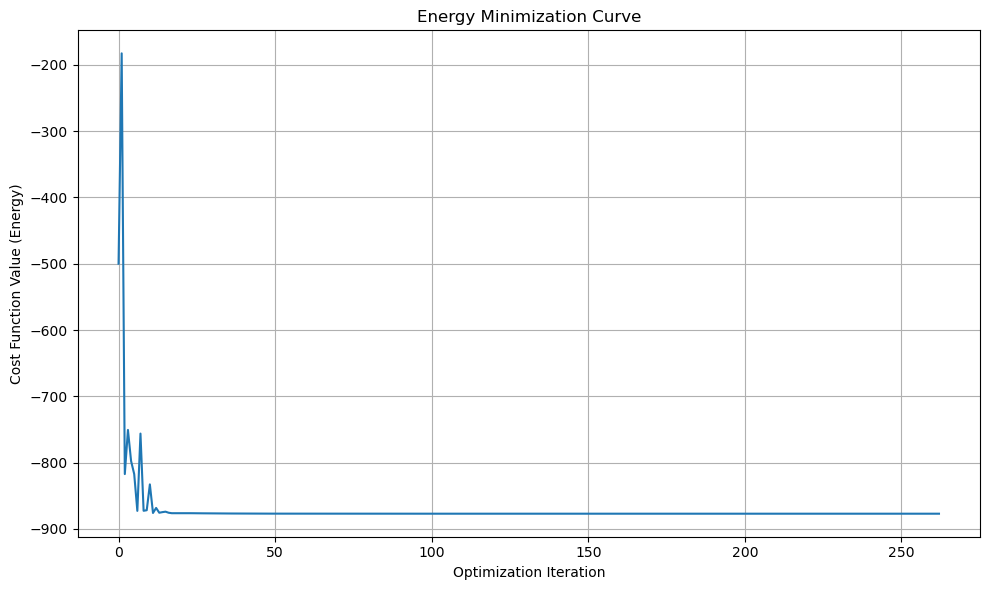

The counts are: {'1': 1024}


C:\Users\selim\Documents\vs_working_dir\QuantumXCT\python\cc_grn_functions\quantum_functions.py:342: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_histogram(counts, bar_labels=True, title=title).show()


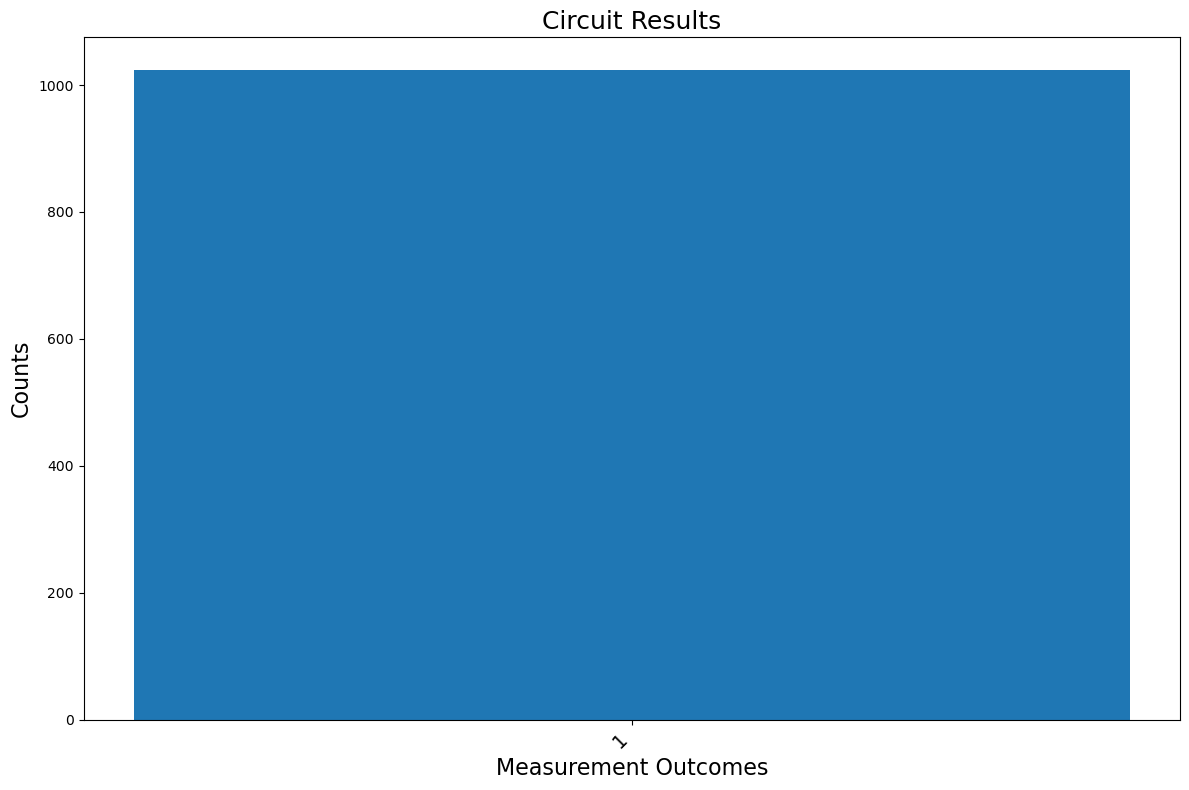

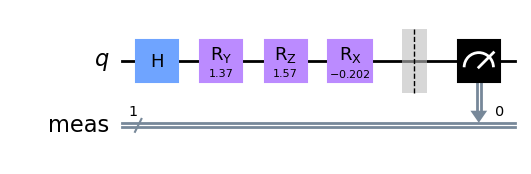

In [4]:
act_percentages = np.ones(circuit.num_qubits)*np.pi*1/2
print(act_percentages)
cirq = create_grn_ansatz(circuit.num_qubits, "hist")


num_qubits = cirq.num_qubits # Get number of qubits from the circuit
min_ones = 0

result_interaction_bfgs, optimized_full_params, cost_values = vqe_solver(
    histogram_data,
    cirq, # Renamed from 'cirquit' for common convention
    act_percentages, # Renamed from 'act_percentages' for consistency with create_parameter_dictionaries_cust
    cost_func_wrapper, # This function needs to be defined to accept the correct arguments (see comments below)
    min_ones_obs=min_ones, # Added as an explicit argument for flexibility
    optimizer_method="COBYLA",# COBYLA | L-BFGS-B
)

# Plot the cost function values
plt.figure(figsize=(10, 6))
plt.plot(cost_values)
plt.xlabel("Optimization Iteration")
plt.ylabel("Cost Function Value (Energy)")
plt.title("Energy Minimization Curve")
plt.grid(True)
plt.tight_layout()
plt.show()
counts, bound_circuit = evaluate_and_plot_ansatz(cirq, optimized_full_params, shots=1024, title="Circuit Results")
bound_circuit.draw(output="mpl", style="clifford", fold=40)  # Show the circuit plot

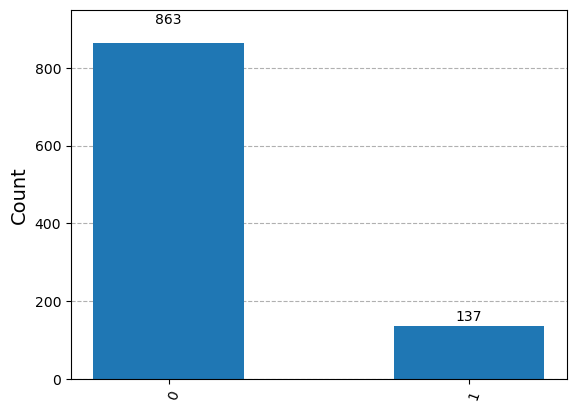

In [5]:
# 1. Create the Bell state (|ψ⟩ = (|00⟩ + |11⟩)/√2)
#circuit = QuantumCircuit(2, 2)
circuit = QuantumCircuit(1)
circuit.ry(np.pi*1/4, 0)
circuit.measure_all()

nshots = 1000
# 3. Simulate the circuit for 1024 shots
simulator = BasicSimulator()
compiled_circuit = transpile(circuit, simulator)
job = simulator.run(compiled_circuit, shots=nshots)
result = job.result()
counts = result.get_counts(circuit)
#circuit.draw(output="mpl", style="clifford", fold=40)
# Create a new Counts object to store the adjusted data
histogram_data = counts
# # Iterate through the original counts and subtract 50 from each value
hist_plt = plot_histogram(histogram_data)
hist_plt

[1.57079633]
Interaction observable CT1 from histogram: SparsePauliOp(['I', 'Z'],
              coeffs=[-500.+0.j, -363.+0.j])
Static Parameters: {}
Variable Parameters (initialized to 0.0): {Parameter(hist_act_0): 1.5707963267948966, Parameter(hist_post_acti2_0): 0.0, Parameter(hist_post_acti_0): 0.0}
Starting optimization with method: COBYLA
Iteration 0: Current cost: -499.99999999999983
Iteration 20: Current cost: -862.9027080405806
Iteration 40: Current cost: -862.9999974351516

Optimization Result:
 message: Optimization terminated successfully.
 success: True
  status: 1
     fun: -862.9999926855719
       x: [ 1.571e+00  1.334e+00 -2.368e-01]
    nfev: 49
   maxcv: 0.0

Final Energy: -862.9999926855719

Optimized Full Parameters:
  hist_act_0: 1.5707773391180329
  hist_post_acti2_0: 1.333821292542393
  hist_post_acti_0: -0.2367751362766889


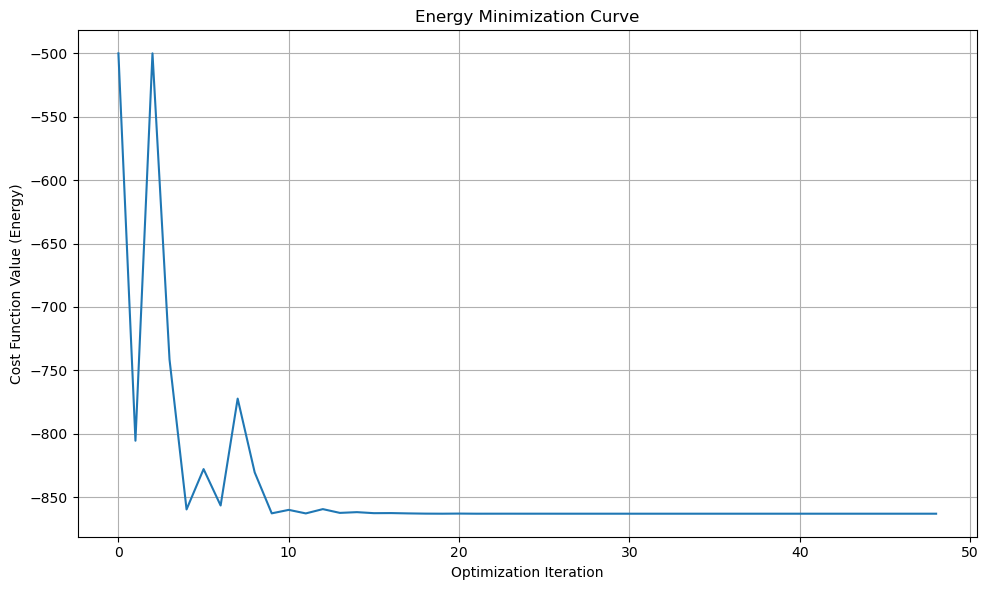

The counts are: {'0': 1024}


C:\Users\selim\Documents\vs_working_dir\QuantumXCT\python\cc_grn_functions\quantum_functions.py:342: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_histogram(counts, bar_labels=True, title=title).show()


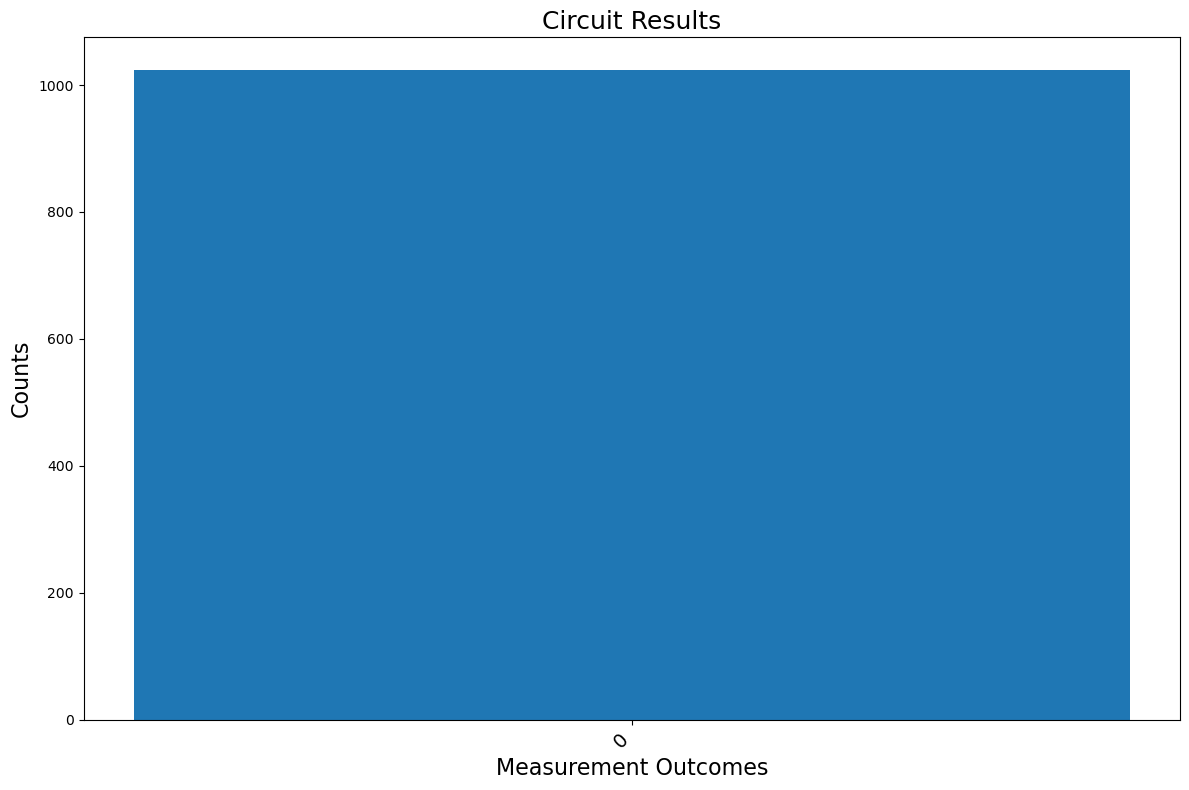

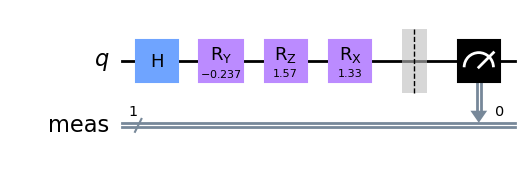

In [6]:
act_percentages = np.ones(circuit.num_qubits)*np.pi*1/2
print(act_percentages)
cirq = create_grn_ansatz(circuit.num_qubits, "hist")


num_qubits = cirq.num_qubits # Get number of qubits from the circuit
min_ones = 0

result_interaction_bfgs, optimized_full_params, cost_values = vqe_solver(
    histogram_data,
    cirq, # Renamed from 'cirquit' for common convention
    act_percentages, # Renamed from 'act_percentages' for consistency with create_parameter_dictionaries_cust
    cost_func_wrapper, # This function needs to be defined to accept the correct arguments (see comments below)
    min_ones_obs=min_ones, # Added as an explicit argument for flexibility
    optimizer_method="COBYLA",# COBYLA | L-BFGS-B
)

# Plot the cost function values
plt.figure(figsize=(10, 6))
plt.plot(cost_values)
plt.xlabel("Optimization Iteration")
plt.ylabel("Cost Function Value (Energy)")
plt.title("Energy Minimization Curve")
plt.grid(True)
plt.tight_layout()
plt.show()
counts, bound_circuit = evaluate_and_plot_ansatz(cirq, optimized_full_params, shots=1024, title="Circuit Results")
bound_circuit.draw(output="mpl", style="clifford", fold=40)  # Show the circuit plot

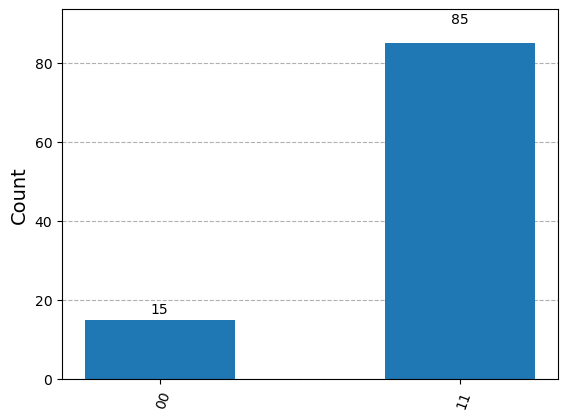

In [7]:
# 1. Create the Bell state (|ψ⟩ = (|00⟩ + |11⟩)/√2)
#circuit = QuantumCircuit(2, 2)
circuit = QuantumCircuit(2)
circuit.ry(np.pi*3/4, 0)
circuit.cx(0, 1)

# 2. Define measurement bases (for a simple Bell test, we'll use the Z basis for both qubits)
# In a more complex Bell test, you would rotate the measurement bases.
#circuit.measure([0, 1], [0, 1])
circuit.measure_all()

# 3. Simulate the circuit for 1024 shots
simulator = BasicSimulator()
compiled_circuit = transpile(circuit, simulator)
job = simulator.run(compiled_circuit, shots=100)
result = job.result()
counts = result.get_counts(circuit)
#circuit.draw(output="mpl", style="clifford", fold=40)
histogram_data = counts
hist_plt = plot_histogram(counts)
hist_plt

[1.57079633 1.57079633]
Interaction observable CT1 from histogram: SparsePauliOp(['II', 'IZ', 'ZI', 'ZZ'],
              coeffs=[-20. +0.j,  17.5+0.j,  17.5+0.j, -30. +0.j])
Static Parameters: {}
Variable Parameters (initialized to 0.0): {Parameter(hist_act_0): 1.5707963267948966, Parameter(hist_act_1): 1.5707963267948966, Parameter(hist_grn_0_1): 0.0, Parameter(hist_grn_1_0): 0.0, Parameter(hist_post_acti2_0): 0.0, Parameter(hist_post_acti2_1): 0.0, Parameter(hist_post_acti_0): 0.0, Parameter(hist_post_acti_1): 0.0}
Starting optimization with method: COBYLA
Iteration 0: Current cost: -19.999999999999993
Iteration 20: Current cost: -84.20286006071727
Iteration 40: Current cost: -84.94756164801596
Iteration 60: Current cost: -84.99747299290657
Iteration 80: Current cost: -84.99988397017249
Iteration 100: Current cost: -84.99998238792034

Optimization Result:
 message: Optimization terminated successfully.
 success: True
  status: 1
     fun: -84.999999337345
       x: [ 1.630e+00  1.619

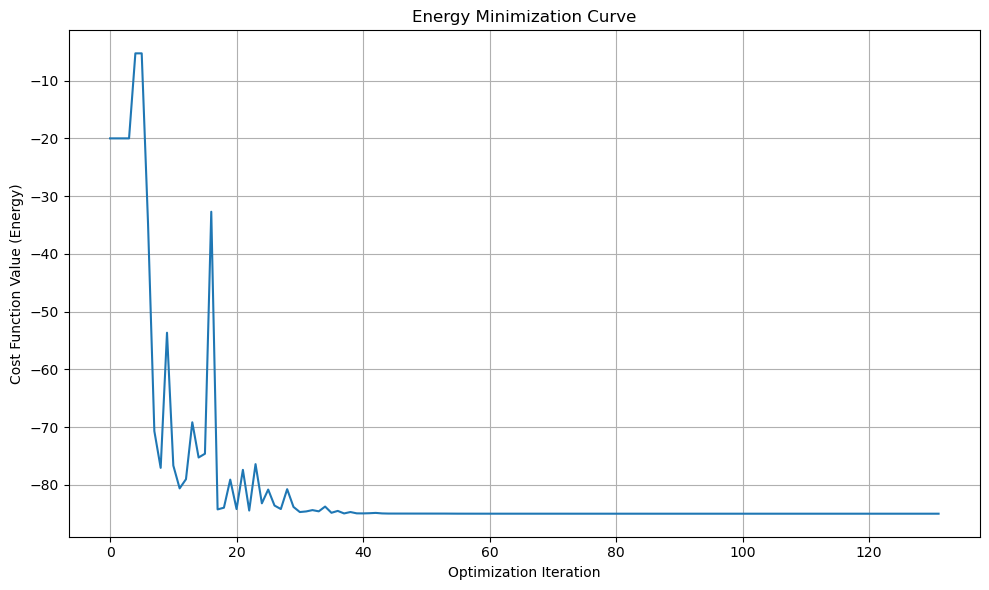

The counts are: {'11': 1024}


C:\Users\selim\Documents\vs_working_dir\QuantumXCT\python\cc_grn_functions\quantum_functions.py:342: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_histogram(counts, bar_labels=True, title=title).show()


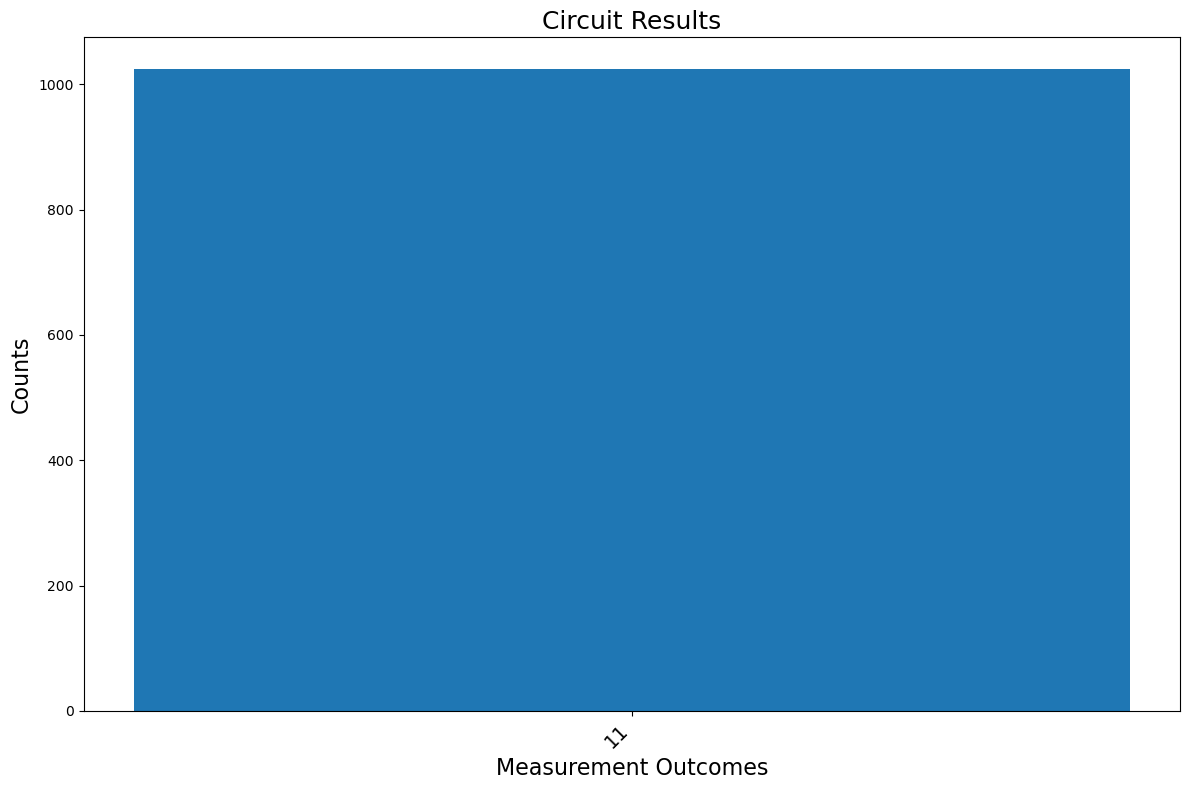

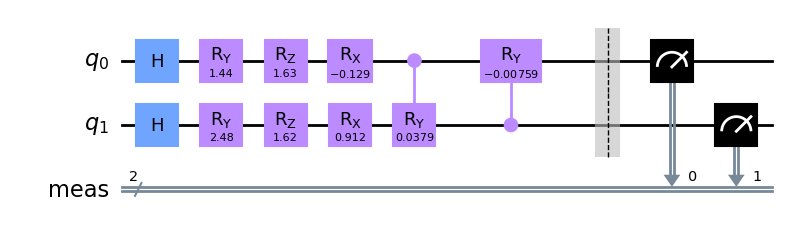

In [8]:
act_percentages = np.ones(circuit.num_qubits)*np.pi*1/2
print(act_percentages)
cirq = create_grn_ansatz(2, "hist")
cirq.draw(output="mpl", style="clifford", fold=40)

num_qubits = cirq.num_qubits # Get number of qubits from the circuit
min_ones = 0

result_interaction_bfgs, optimized_full_params, cost_values = vqe_solver(
    histogram_data,
    cirq, # Renamed from 'cirquit' for common convention
    act_percentages, # Renamed from 'act_percentages' for consistency with create_parameter_dictionaries_cust
    cost_func_wrapper, # This function needs to be defined to accept the correct arguments (see comments below)
    min_ones_obs=min_ones, # Added as an explicit argument for flexibility
    optimizer_method="COBYLA",# COBYLA | L-BFGS-B
)

# Plot the cost function values
plt.figure(figsize=(10, 6))
plt.plot(cost_values)
plt.xlabel("Optimization Iteration")
plt.ylabel("Cost Function Value (Energy)")
plt.title("Energy Minimization Curve")
plt.grid(True)
plt.tight_layout()
plt.show()
counts, bound_circuit = evaluate_and_plot_ansatz(cirq, optimized_full_params, shots=1024, title="Circuit Results")
bound_circuit.draw(output="mpl", style="clifford", fold=40)  # Show the circuit plot

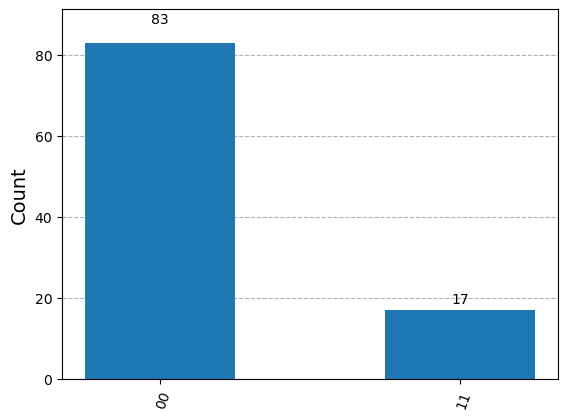

In [9]:
# 1. Create the Bell state (|ψ⟩ = (|00⟩ + |11⟩)/√2)
#circuit = QuantumCircuit(2, 2)
circuit = QuantumCircuit(2)
circuit.ry(np.pi*1/4, 0)
circuit.cx(0, 1)

# 2. Define measurement bases (for a simple Bell test, we'll use the Z basis for both qubits)
# In a more complex Bell test, you would rotate the measurement bases.
#circuit.measure([0, 1], [0, 1])
circuit.measure_all()

# 3. Simulate the circuit for 1024 shots
simulator = BasicSimulator()
compiled_circuit = transpile(circuit, simulator)
job = simulator.run(compiled_circuit, shots=100)
result = job.result()
counts = result.get_counts(circuit)
#circuit.draw(output="mpl", style="clifford", fold=40)
histogram_data = counts
hist_plt = plot_histogram(counts)
hist_plt

[1.57079633 1.57079633]
Interaction observable CT1 from histogram: SparsePauliOp(['II', 'IZ', 'ZI', 'ZZ'],
              coeffs=[-20. +0.j, -16.5+0.j, -16.5+0.j, -30. +0.j])
Static Parameters: {}
Variable Parameters (initialized to 0.0): {Parameter(hist_act_0): 1.5707963267948966, Parameter(hist_act_1): 1.5707963267948966, Parameter(hist_grn_0_1): 0.0, Parameter(hist_grn_1_0): 0.0, Parameter(hist_post_acti2_0): 0.0, Parameter(hist_post_acti2_1): 0.0, Parameter(hist_post_acti_0): 0.0, Parameter(hist_post_acti_1): 0.0}
Starting optimization with method: COBYLA
Iteration 0: Current cost: -19.999999999999996
Iteration 20: Current cost: -77.28490237013405
Iteration 40: Current cost: -82.83497305983683
Iteration 60: Current cost: -82.99455753068649
Iteration 80: Current cost: -82.99879852356993
Iteration 100: Current cost: -82.99993915405473

Optimization Result:
 message: Optimization terminated successfully.
 success: True
  status: 1
     fun: -82.99999979109732
       x: [ 1.571e+00  1.5

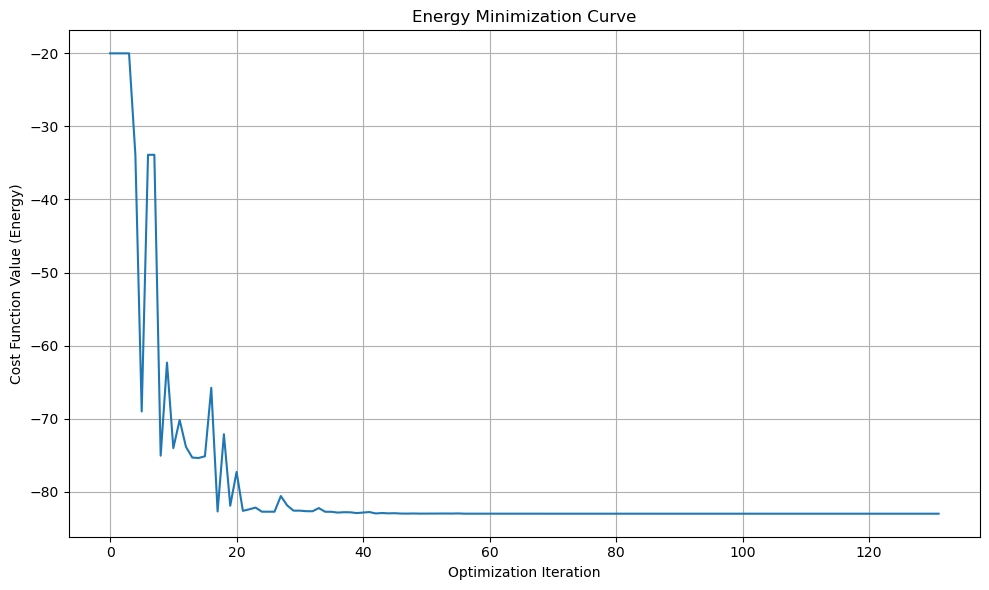

The counts are: {'00': 1024}


C:\Users\selim\Documents\vs_working_dir\QuantumXCT\python\cc_grn_functions\quantum_functions.py:342: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_histogram(counts, bar_labels=True, title=title).show()


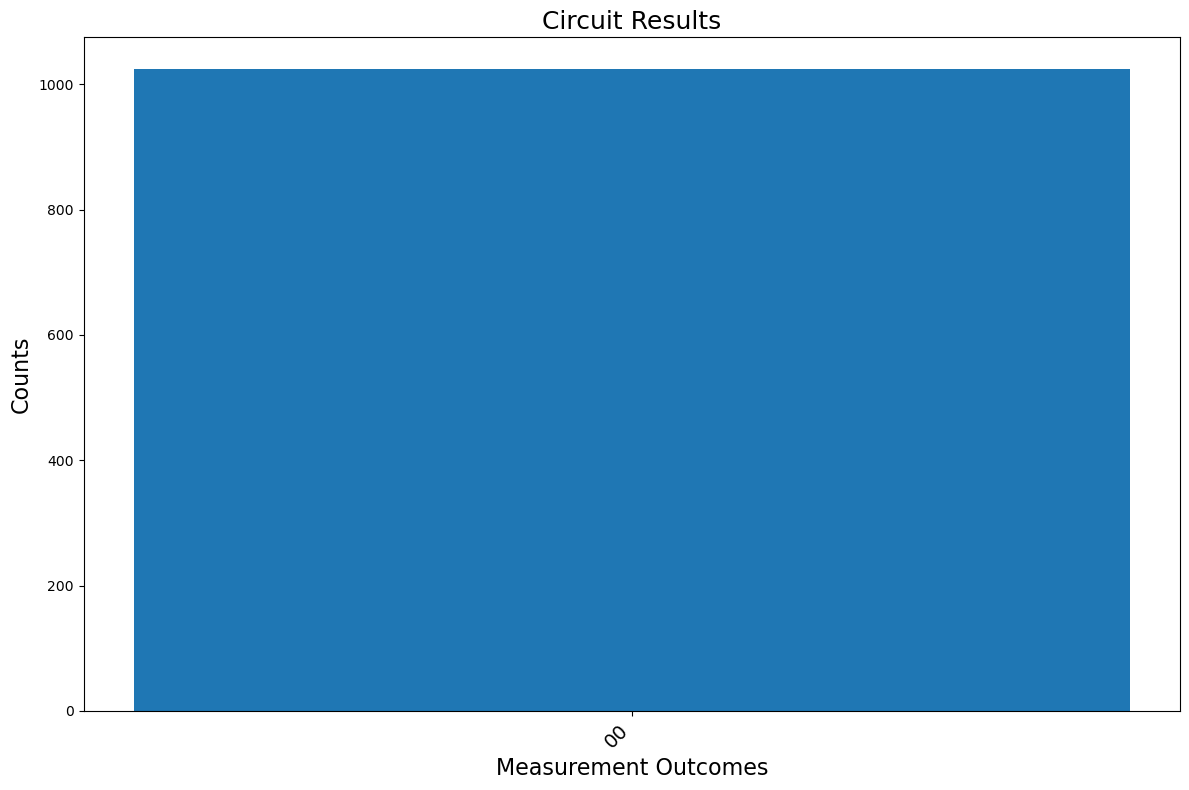

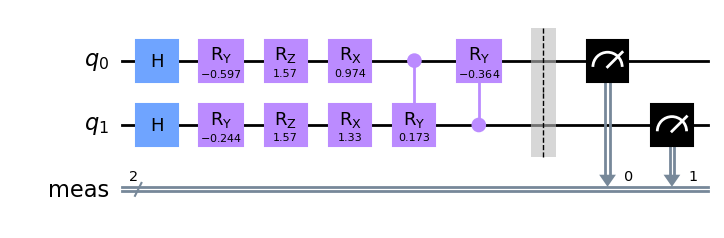

In [10]:
act_percentages = np.ones(circuit.num_qubits)*np.pi*1/2
print(act_percentages)
cirq = create_grn_ansatz(2, "hist")
cirq.draw(output="mpl", style="clifford", fold=40)

num_qubits = cirq.num_qubits # Get number of qubits from the circuit
min_ones = 0

result_interaction_bfgs, optimized_full_params, cost_values = vqe_solver(
    histogram_data,
    cirq, # Renamed from 'cirquit' for common convention
    act_percentages, # Renamed from 'act_percentages' for consistency with create_parameter_dictionaries_cust
    cost_func_wrapper, # This function needs to be defined to accept the correct arguments (see comments below)
    min_ones_obs=min_ones, # Added as an explicit argument for flexibility
    optimizer_method="COBYLA",# COBYLA | L-BFGS-B
)

# Plot the cost function values
plt.figure(figsize=(10, 6))
plt.plot(cost_values)
plt.xlabel("Optimization Iteration")
plt.ylabel("Cost Function Value (Energy)")
plt.title("Energy Minimization Curve")
plt.grid(True)
plt.tight_layout()
plt.show()
counts, bound_circuit = evaluate_and_plot_ansatz(cirq, optimized_full_params, shots=1024, title="Circuit Results")
bound_circuit.draw(output="mpl", style="clifford", fold=40)  # Show the circuit plot

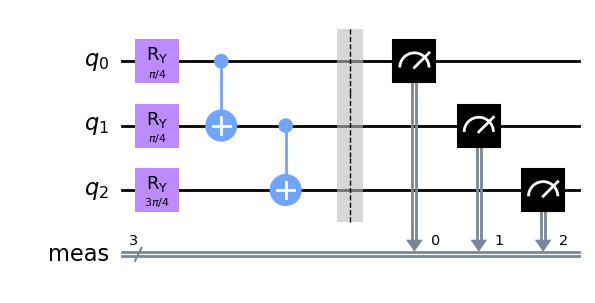

In [22]:
from qiskit import QuantumCircuit, transpile
from qiskit.providers.basic_provider import BasicSimulator
import numpy as np
import matplotlib.pyplot as plt

# 1. Create the 3-qubit GHZ-like state
# |ψ⟩ = (|000⟩ + |111⟩)/√2
circuit = QuantumCircuit(3) # Initialize with 3 qubits and 3 classical bits

circuit.ry(np.pi*1/4, 0)  # Apply a rotation to the first qubit
circuit.ry(np.pi*1/4, 1)  # Apply a rotation to the second qubit
circuit.ry(np.pi*3/4, 2)  # Apply a rotation to the third qubit
#circuit.h(3)
#circuit.x(1)
#circuit.x(2)
circuit.cx(0, 1)
circuit.cx(1, 2)


# 2. Measure all three qubits
circuit.measure_all()

# 3. Simulate the circuit for 1024 shots
simulator = BasicSimulator()
compiled_circuit = transpile(circuit, simulator)
job = simulator.run(compiled_circuit, shots=1024)
result = job.result()
counts = result.get_counts(circuit)
circuit.draw(output="mpl", style="clifford", fold=40)


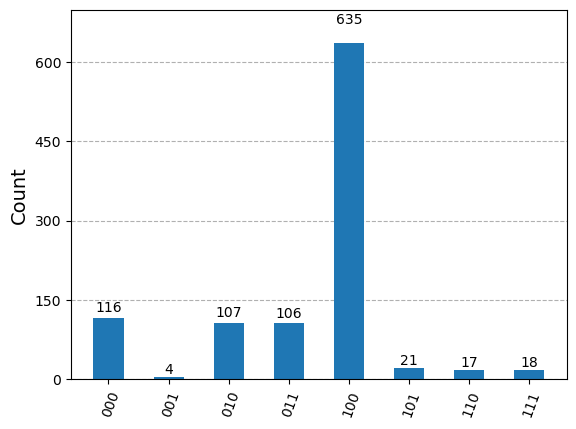

In [23]:
histogram_data = counts
hist_plt = plot_histogram(counts)
hist_plt

[3.14159265 3.14159265 3.14159265]


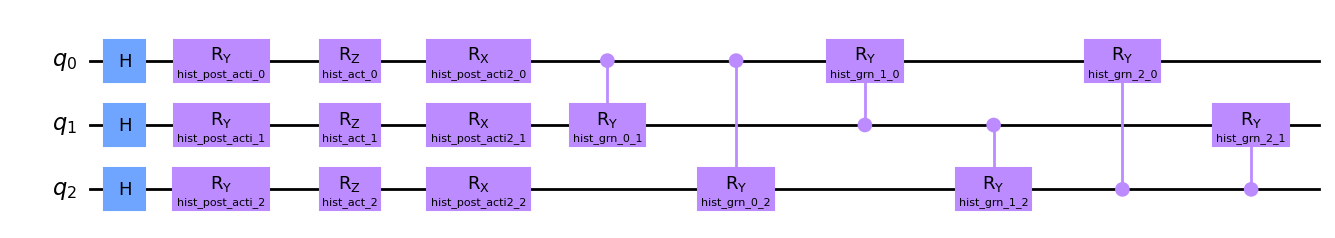

In [24]:
act_percentages = np.ones(circuit.num_qubits)*np.pi
print(act_percentages)
cirq = create_grn_ansatz(circuit.num_qubits, "hist")
cirq.draw(output="mpl", style="clifford", fold=40)

Interaction observable CT1 from histogram: SparsePauliOp(['III', 'IIZ', 'IZI', 'IZZ', 'ZII', 'ZIZ', 'ZZI', 'ZZZ'],
              coeffs=[-128.  +0.j,  -90.75+0.j,  -66.  +0.j,  -90.75+0.j,   44.75+0.j,
   62.5 +0.j,   89.25+0.j,   63.  +0.j])
Static Parameters: {}
Variable Parameters (initialized to 0.0): {Parameter(hist_act_0): 3.141592653589793, Parameter(hist_act_1): 3.141592653589793, Parameter(hist_act_2): 3.141592653589793, Parameter(hist_grn_0_1): 0.0, Parameter(hist_grn_0_2): 0.0, Parameter(hist_grn_1_0): 0.0, Parameter(hist_grn_1_2): 0.0, Parameter(hist_grn_2_0): 0.0, Parameter(hist_grn_2_1): 0.0, Parameter(hist_post_acti2_0): 0.0, Parameter(hist_post_acti2_1): 0.0, Parameter(hist_post_acti2_2): 0.0, Parameter(hist_post_acti_0): 0.0, Parameter(hist_post_acti_1): 0.0, Parameter(hist_post_acti_2): 0.0}
Starting optimization with method: COBYLA
Iteration 0: Current cost: -127.99999999999993
Iteration 20: Current cost: -414.43098660208
Iteration 40: Current cost: -614.453869372982

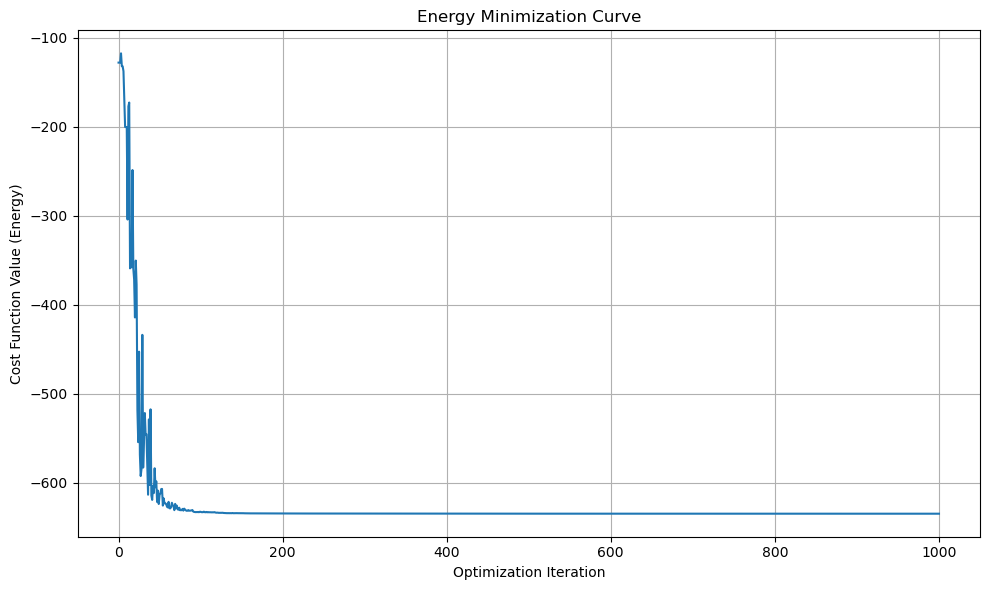

In [25]:
num_qubits = cirq.num_qubits # Get number of qubits from the circuit
min_ones = 0

result_interaction_bfgs, optimized_full_params, cost_values = vqe_solver(
    histogram_data,
    cirq, # Renamed from 'cirquit' for common convention
    act_percentages, # Renamed from 'act_percentages' for consistency with create_parameter_dictionaries_cust
    cost_func_wrapper, # This function needs to be defined to accept the correct arguments (see comments below)
    min_ones_obs=min_ones, # Added as an explicit argument for flexibility
    optimizer_method="COBYLA",# COBYLA | L-BFGS-B
)

# Plot the cost function values
plt.figure(figsize=(10, 6))
plt.plot(cost_values)
plt.xlabel("Optimization Iteration")
plt.ylabel("Cost Function Value (Energy)")
plt.title("Energy Minimization Curve")
plt.grid(True)
plt.tight_layout()
plt.show()

The counts are: {'100': 1024}


C:\Users\selim\Documents\vs_working_dir\QuantumXCT\python\cc_grn_functions\quantum_functions.py:342: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_histogram(counts, bar_labels=True, title=title).show()


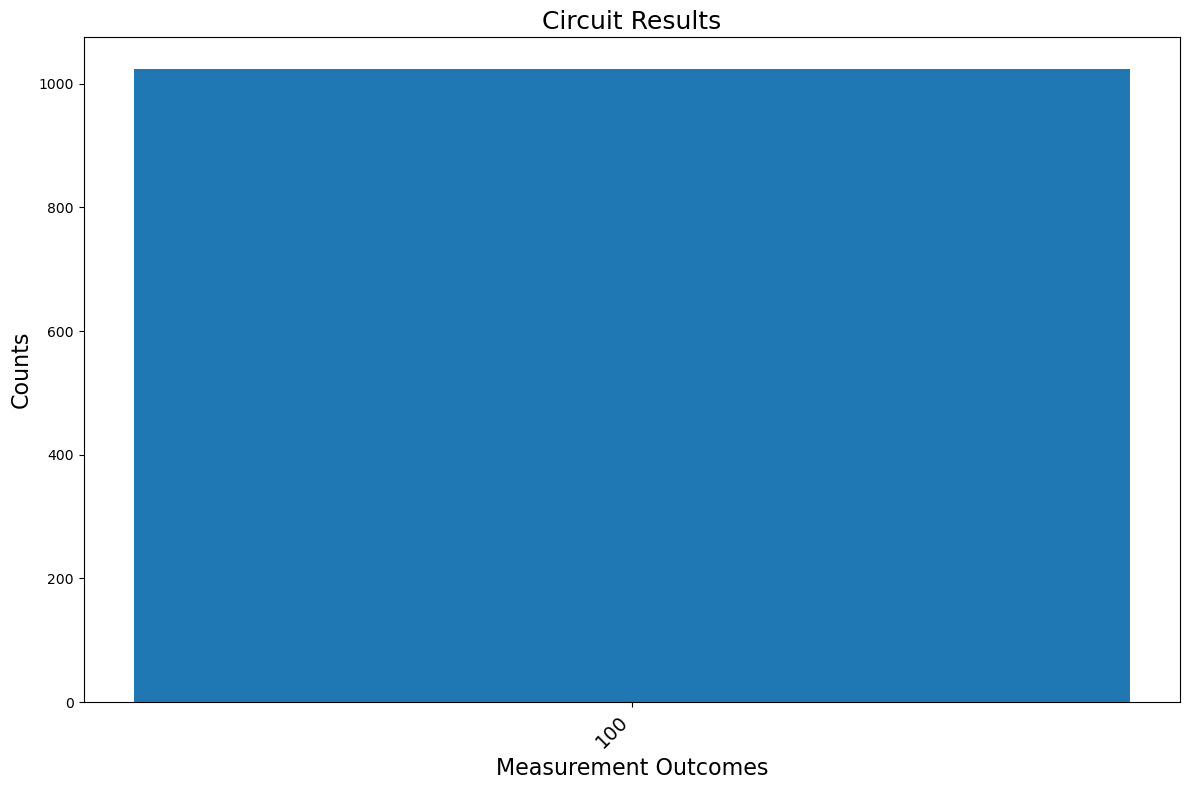

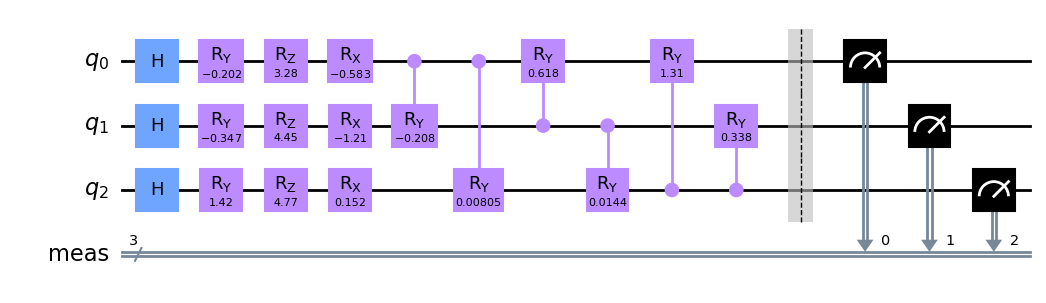

In [26]:
counts, bound_circuit = evaluate_and_plot_ansatz(cirq, optimized_full_params, shots=1024, title="Circuit Results")
bound_circuit.draw(output="mpl", style="clifford", fold=40)  # Show the circuit plot


Circuit Diagram (with Parameters):


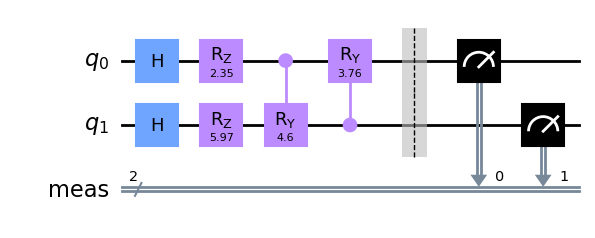

In [16]:
from qiskit import QuantumCircuit, transpile
from qiskit.providers.basic_provider import BasicSimulator
import numpy as np
import matplotlib.pyplot as plt
from qiskit.circuit import Parameter # Import Parameter

# Set a random seed for reproducibility of angles
np.random.seed(42)

# Function to generate a random numerical value for parameters
def get_random_parameter_value():
    return np.random.uniform(0, 2 * np.pi)

# --- Define the number of qubits here ---
num_qubits = 2 # You can change this value to any desired number of qubits

# 1. Create the quantum circuit
# Initialize with num_qubits quantum bits and num_qubits classical bits
circuit = QuantumCircuit(num_qubits)
# num_features is now directly equivalent to num_qubits
num_features = circuit.num_qubits

# Dictionary to store all parameters and their initial static values
parameter_values = {}
all_qiskit_parameters = [] # To keep track of the Parameter objects created

# Define parameters for the initial Rz gates (activation parameters)
params_act = [Parameter(f"act_{i}") for i in range(num_features)]
for param in params_act:
    parameter_values[param] = get_random_parameter_value()
    all_qiskit_parameters.append(param)

# Define a placeholder for cell_type, as it was not defined in your snippet
cell_type = "ex_cell"

# --- Circuit Construction ---

# Apply Hadamard gates and Rz rotations to each qubit
for i in range(num_features):
    circuit.h(i)
    circuit.rz(params_act[i], i)  # Use RZ for activation with defined parameters

# Gene interaction CRy gates
# This loop structure creates CRy gates between all unique ordered pairs of qubits
for i in range(num_features):
    for j in range(num_features):
        if i != j:
            param_name = f'{cell_type}_grn_{i}_{j}'
            param = Parameter(param_name)
            circuit.cry(param, i, j) # Using CRy as per your snippet
            parameter_values[param] = get_random_parameter_value() # Assign a static random value
            all_qiskit_parameters.append(param)

# 2. Measure all qubits
# This is a more general way to measure all qubits into all classical bits
circuit.measure_all()

# 3. Simulate the circuit for 1024 shots
simulator = BasicSimulator()

# IMPORTANT: Assign the static random values to the parameters
# This creates a new circuit where all parameters are replaced by their numerical values.
bound_circuit = circuit.assign_parameters(parameter_values)

# Transpile and run the bound circuit
compiled_circuit = transpile(bound_circuit, simulator)
job = simulator.run(compiled_circuit, shots=1024)
result = job.result()
counts = result.get_counts(bound_circuit) # Get counts from the bound circuit
# Draw the circuit
print("\nCircuit Diagram (with Parameters):")
# Draw the original circuit with parameters for clarity, before binding
bound_circuit.draw(output="mpl", style="clifford", fold=40)

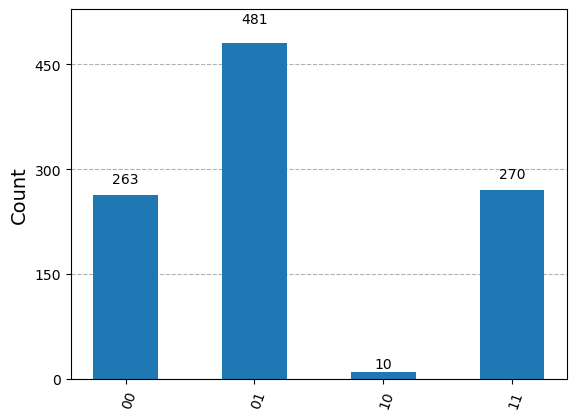

In [17]:
histogram_data = counts
hist_plt = plot_histogram(counts)
hist_plt

[3.14159265 3.14159265]


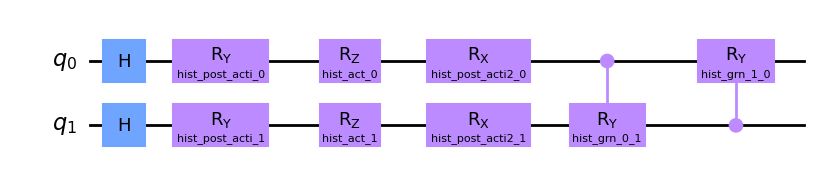

In [18]:
act_percentages = np.ones(num_qubits)*np.pi
#act_percentages = np.array([2.35, 5.97])
print(act_percentages)
cirq = create_grn_ansatz(num_qubits, "hist")
cirq.draw(output="mpl", style="clifford", fold=40)

Interaction observable from histogram: SparsePauliOp(['II', 'IZ', 'ZI', 'ZZ'],
              coeffs=[-187.75+0.j,  187.75+0.j,  -47.75+0.j,   57.75+0.j])
Static Parameters: {}
Variable Parameters (initialized to 0.0): {Parameter(hist_act_0): 3.141592653589793, Parameter(hist_act_1): 3.141592653589793, Parameter(hist_grn_0_1): 0.0, Parameter(hist_grn_1_0): 0.0, Parameter(hist_post_acti2_0): 0.0, Parameter(hist_post_acti2_1): 0.0, Parameter(hist_post_acti_0): 0.0, Parameter(hist_post_acti_1): 0.0}

Optimization Result:
 message: Optimization terminated successfully.
 success: True
  status: 1
     fun: -480.99999981524934
       x: [ 2.491e+00  2.159e+00  4.026e-01  2.856e-01  9.280e-08
            6.921e-01  1.571e+00 -7.871e-01]
    nfev: 131
   maxcv: 0.0

Optimized Full Parameters:
  hist_act_0: 2.490671091353323
  hist_act_1: 2.1592509696883013
  hist_grn_0_1: 0.40256752189494843
  hist_grn_1_0: 0.28561340378376815
  hist_post_acti2_0: 9.27955051716024e-08
  hist_post_acti2_1: 0.692

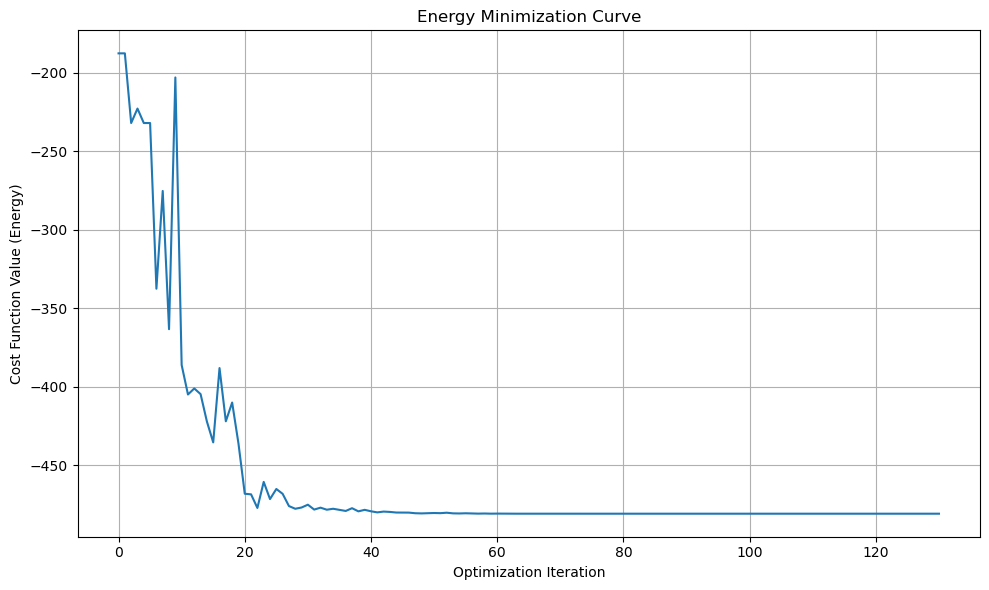

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit.primitives import StatevectorEstimator
from scipy.optimize import minimize

# Get number of qubits from the circuit
min_ones = 1
# 1. Create interaction observable
interaction_observable = create_interaction_observable_from_histogram( joint_counts=histogram_data, 
                                                                      num_features=num_qubits, 
                                                                      min_ones=min_ones)
print("Interaction observable from histogram:", interaction_observable)

# 2. Create static and variable parameter dictionaries
# Ensure you are using create_parameter_dictionaries_cust here, not create_parameter_dictionaries
#static_params, variable_params = create_parameter_dictionaries(cirq, act_percentages)
static_params, variable_params = create_parameter_dictionaries_cust(cirq, act_percentages)


print("Static Parameters:", static_params)
print("Variable Parameters (initialized to 0.0):", variable_params)

# 3. Initialize Qiskit Estimator
estimator = StatevectorEstimator()

# 4. Prepare initial guess for optimization
x0_interaction = np.array(list(variable_params.values()))
variable_param_objects = list(variable_params.keys())

# 5. Create initial full parameter dictionary (this is mainly for initial print and structure)
all_params = static_params.copy()
all_params.update(dict(zip(variable_param_objects, x0_interaction)))

cost_values = []
# Call minimize with args
result_interaction_bfgs = minimize(
    cost_func_wrapper,
    x0_interaction,
    args=(all_params, cirq, interaction_observable, estimator, variable_params), # Pass all the arguments as a tuple
    method="COBYLA", # COBYLA | L-BFGS-B
    callback=lambda xk: cost_values.append(cost_func_wrapper(xk, all_params, cirq, interaction_observable, estimator, variable_params))
)

print("\nOptimization Result:")
print(result_interaction_bfgs)

# 7. Update the full parameter dictionary with optimized variable parameters
optimized_variable_parameters = result_interaction_bfgs.x

# Construct the final optimized full parameter dictionary
optimized_full_params = static_params.copy()
for param_obj, value in zip(variable_param_objects, optimized_variable_parameters):
    optimized_full_params[param_obj] = value

print("\nOptimized Full Parameters:")
# Print optimized parameters by name for readability
for param, value in optimized_full_params.items():
    print(f"  {param.name}: {value}")

import matplotlib.pyplot as plt

# Plot the cost function values
plt.figure(figsize=(10, 6))
plt.plot(cost_values)
plt.xlabel("Optimization Iteration")
plt.ylabel("Cost Function Value (Energy)")
plt.title("Energy Minimization Curve")
plt.grid(True)
plt.tight_layout()
plt.show()

The counts are: {'01': 1024}


C:\Users\selim\Documents\vs_working_dir\QuantumXCT\python\cc_grn_functions\quantum_functions.py:342: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_histogram(counts, bar_labels=True, title=title).show()


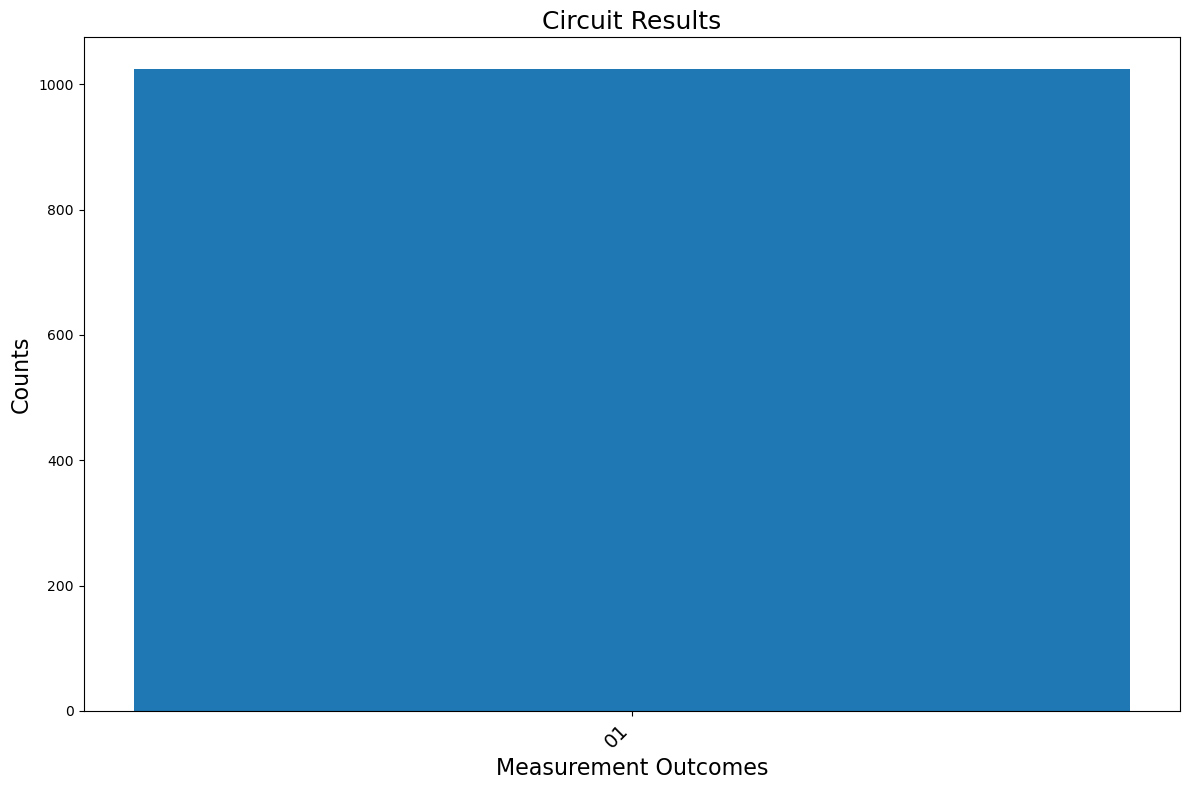

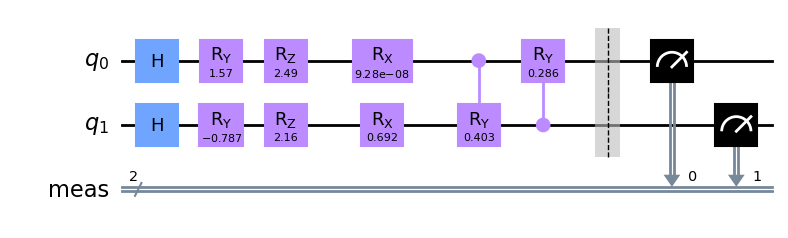

In [20]:
counts, bound_circuit = evaluate_and_plot_ansatz(cirq, optimized_full_params, shots=1024, title="Circuit Results")

bound_circuit.draw(output="mpl", style="clifford", fold=40)  # Show the circuit plot